# Day 1 — Supervised Learning Concepts & the Scikit-learn API

Setting up the ML workflow on a weather dataset: separating features and target, and performing an 80/20 train/test split.

## Loading the Dataset and Initial Inspection
Load the weather dataset and take a first look at its shape, structure, data types, and missing values before doing anything else.

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [14]:
df = pd.read_csv("Weather Dataset.csv")
df.head()


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


.head() shows the first rows of the dataset, giving an initial look at the available columns: Date/Time, Temp_C, Dew Point Temp_C, Rel Hum_%, Wind Speed_km/h, Visibility_km, Press_kPa, and Weather.

In [15]:
print(df.shape)
df.dtypes

(8784, 8)


Date/Time               str
Temp_C              float64
Dew Point Temp_C    float64
Rel Hum_%             int64
Wind Speed_km/h       int64
Visibility_km       float64
Press_kPa           float64
Weather                 str
dtype: object

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   str    
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   str    
dtypes: float64(4), int64(2), str(2)
memory usage: 549.1 KB


.info() confirms the same 8 columns and 8,784 non-null entries in every one of them — a first signal that the dataset has no missing values.

In [17]:
df.isna().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

.isna().sum() confirms there are zero missing values across every column, so no imputation is needed before moving on.

## Exploring the Relationship Between Dew Point and Temperature
Before building anything, visualize how Dew Point Temp_C relates to Temp_C with a scatter plot, since dew point is a strong physical driver of air temperature.

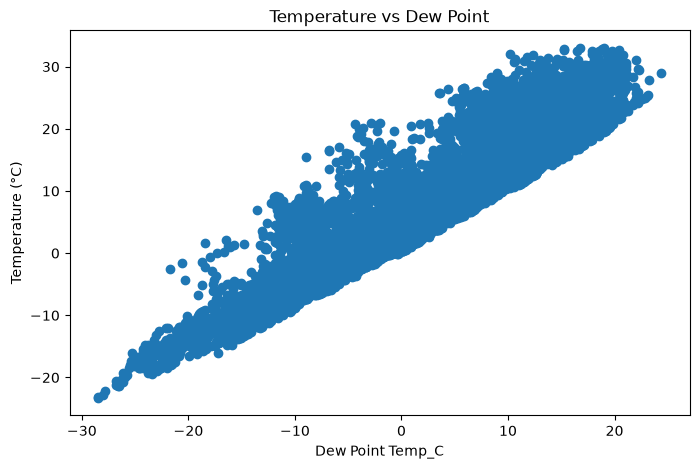

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df["Dew Point Temp_C"], df["Temp_C"])

plt.xlabel("Dew Point Temp_C")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Dew Point")

plt.show()

The scatter plot shows a clear, tight, positive linear relationship — as dew point rises, temperature rises with it. This is exactly the kind of strong relationship a regression model should be able to pick up on.

In [19]:
df["Temp_C"].corr(df["Dew Point Temp_C"])

np.float64(0.9327141498173762)

The correlation between Temp_C and Dew Point Temp_C is about **0.93** — a very strong positive linear relationship, confirming what the scatter plot showed visually. This makes Dew Point Temp_C likely to be one of the most useful features for predicting temperature.

## Step 1 — Separating Features (X) and Target (y)
Split the dataset into the features X (everything except Temp_C) and the target y (Temp_C, the value to predict).

In [20]:
X = df.drop("Temp_C", axis=1)   # features: everything except the target
y = df["Temp_C"] 

X now holds every column except Temp_C , and y holds only the Temp_C column — the target the model will learn to predict from the remaining features.

In [21]:
X.head()

,Date/Time,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-3.3,88,7,4.8,101.23,Fog


`X.head()` confirms `Temp_C` is no longer present — only the feature columns remain.

In [22]:
y.head()

0   -1.8
1   -1.8
2   -1.8
3   -1.5
4   -1.5
Name: Temp_C, dtype: float64

y.head() confirms y is just the single Temp_C column, matching the first few rows of the original dataset.

## Step 2 — 80/20 Train/Test Split
Perform an 80/20 train/test split with random_state=42 fixed, so the same split is reproducible every time the notebook runs.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

train_test_split has now produced four separate objects — X_train, X_test, y_train, and y_test — with 80% of the rows held out for training and 20% reserved for testing.

## Step 3 — Confirming the Shapes
Print the shapes of X_train, X_test, y_train, and y_test to confirm the split is consistent — the same number of rows in X_train as y_train, and in X_test as y_test.

In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7027, 7)
X_test: (1757, 7)
y_train: (7027,)
y_test: (1757,)


**Result:** X_train has 7,027 rows, X_test has 1,757 rows — an 80/20 split of the 8,784 total rows, as expected. y_train and y_test match X_train and X_test row-for-row (7,027 and 1,757 respectively), confirming the features and target stayed correctly aligned through the split.

## Step 4 — Why the Model Must Never See the Test Set During Training

The test set exists to answer one question: how will this model perform on data it has never encountered before? If the model is trained (or even peeked at) using the test set, that question can no longer be honestly answered — the model could simply be memorizing those specific rows instead of learning the real underlying relationship between Dew Point Temp_C and Temp_C.

In that case, model.score(X_test, y_test) would report an overly optimistic result, because the model is being graded on an exam it already saw the answers to. That score would be meaningless as an estimate of real-world performance — the model might then fail badly on genuinely new weather readings after deployment, even though the test score said it was doing great.

Keeping X_test and y_test completely unseen until the final evaluation is what makes the train/test split an honest, trustworthy measure of how the model will actually generalize.